## This is a sample Machine Learning project that exemplifies how to proceed Hierarchical Multilevel Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statstests.process import stepwise
from scipy import stats
from scipy.stats import gaussian_kde
import time
import imageio
from IPython.display import Image, display
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Performance = f(month, extra_class_activity, professor_experience_years). Hierarchical Linear Models (HLM) or Generalized Linear Mixed Models (GLMM). Multilevel (Nested) Regression Analysis.

This is a simple use-case for Generalized Linear Mixed Models (GLMM) of type Hierarchical Linear Model with 3 levels (HLM3). Data level layers are: period (month) (level 1) (subscript t), student (level 2) (subscript j) and school (level 3) (subscript k). X (level 1), W (level 2) and Z (level 3) predictive variables are: month (jk) (period level), extra_class_activity (jk) (student level) and professor_experience_years (k) (school level). And dependent variable is performance. Student and school variables are labels (ids). The month is a period-level time series count - repeated measures, nested into each student, nested into each school. In terms of observations, we have thus four months-period nested into each of 610 students, distributed into 15 schools = 2440 observation rows.

In [2]:
period_student_school_df = pd.read_csv('period-student-school-performance.csv', delimiter=',')
# pd.set_option('display.max_rows', None)
period_student_school_df

,school,student,month,performance,extra_class_activity,professor_experience_years
0,1,1,1,35.400002,no,2
1,1,1,2,44.400002,no,2
2,1,1,3,46.400002,no,2
3,1,1,4,52.400002,no,2
4,1,2,1,74.900002,no,2
...,...,...,...,...,...,...
2435,15,609,4,100.000000,yes,9
2436,15,610,1,87.599998,yes,9
2437,15,610,2,92.599998,yes,9
2438,15,610,3,94.599998,yes,9


In [3]:
period_student_school_df['student'] = period_student_school_df['student'].astype('category')
period_student_school_df['school'] = period_student_school_df['school'].astype('category')
period_student_school_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2440 entries, 0 to 2439
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   school                      2440 non-null   category
 1   student                     2440 non-null   category
 2   month                       2440 non-null   int64   
 3   performance                 2440 non-null   float64 
 4   extra_class_activity        2440 non-null   str     
 5   professor_experience_years  2440 non-null   int64   
dtypes: category(2), float64(1), int64(2), str(1)
memory usage: 88.4 KB


In [4]:
period_student_school_df.describe()

,month,performance,professor_experience_years
count,2440.000000,2440.000000,2440.000000
mean,2.500000,68.341352,9.027869
std,1.118263,22.981531,7.655618
min,1.000000,10.500000,2.000000
25%,1.750000,49.574999,2.000000
50%,2.500000,70.300003,9.000000
75%,3.250000,88.500000,18.000000
max,4.000000,100.000000,20.000000


In [5]:
# analysing unbalacing of data regarding students per period
period_student_school_df.groupby('month')['student'].count().reset_index()

,month,student
0,1,610
1,2,610
2,3,610
3,4,610


In [6]:
# analysing unbalacing of data regarding students per school
period_student_school_df.groupby('school')['student'].count().reset_index()

,school,student
0,1,188
1,2,100
2,3,192
3,4,80
4,5,192
5,6,120
6,7,112
7,8,140
8,9,176
9,10,132


In [7]:
# analysing mean performance per period
period_student_school_df.groupby('month')['performance'].mean().reset_index()

,month,performance
0,1,61.654918
1,2,66.366065
2,3,70.611147
3,4,74.733279


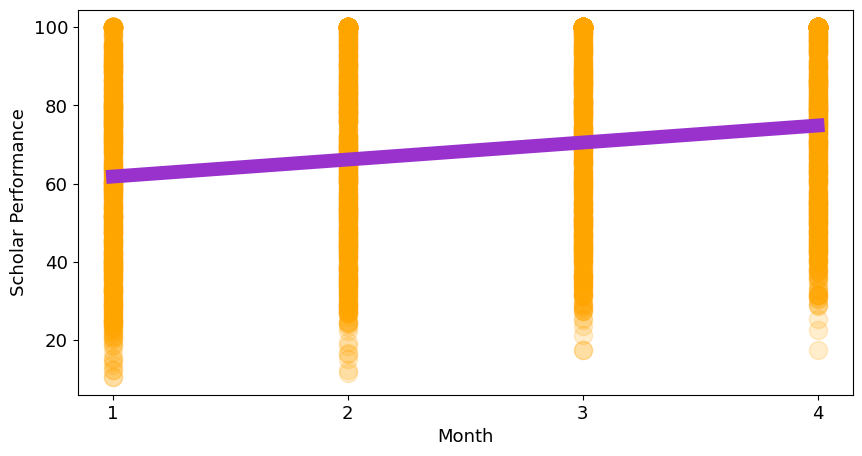

In [8]:
# Plot graph with the evolution of student mean performance in each period (linear adjust)
plt.figure(figsize=(10,5))
sns.regplot(x=period_student_school_df['month'], y=period_student_school_df['performance'],
            ci=None, marker='o',
            scatter_kws={'color':'orange', 's':170, 'alpha':0.2},
            line_kws={'color':'darkorchid', 'linewidth':10})
plt.xlabel('Month', fontsize=13)
plt.ylabel('Scholar Performance', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.xticks(np.arange(1, 5, 1))
plt.show()

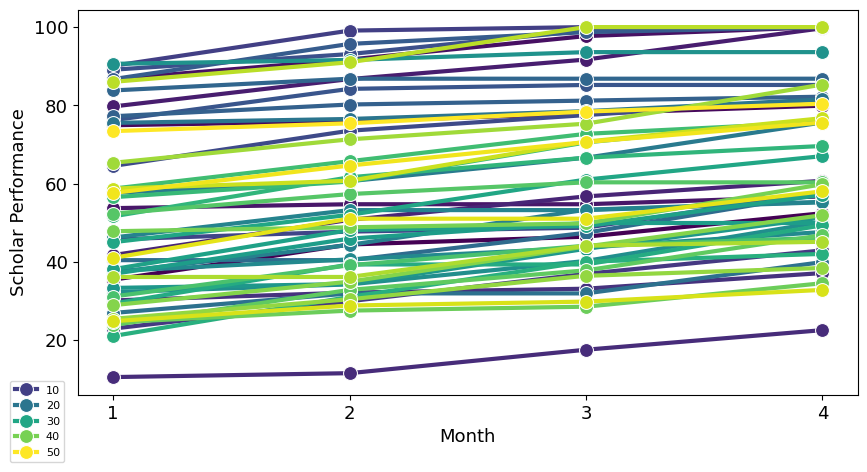

In [9]:
# temporal evolution of mean scholar performance of the 50 first students at the sample (only 50 for better 
# visualization)

period_student_school_df['student'] = period_student_school_df['student'].astype('int')
sample_df = period_student_school_df[period_student_school_df['student'] <= 50]
period_student_school_df['student'] = period_student_school_df['student'].astype('category')

plt.figure(figsize=(13,5))
sns.lineplot(x='month', y='performance', data=sample_df,
             hue='student', marker="o", palette='viridis',
             markersize=10, linewidth=3)
plt.ylabel('Scholar Performance', fontsize=13)
plt.xlabel('Month', fontsize=13)
plt.legend(loc='upper right', bbox_to_anchor=(-0.01, 0.05), fontsize=8)
plt.subplots_adjust(left=0.3)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.xticks(np.arange(1, 5, 1))
plt.show()

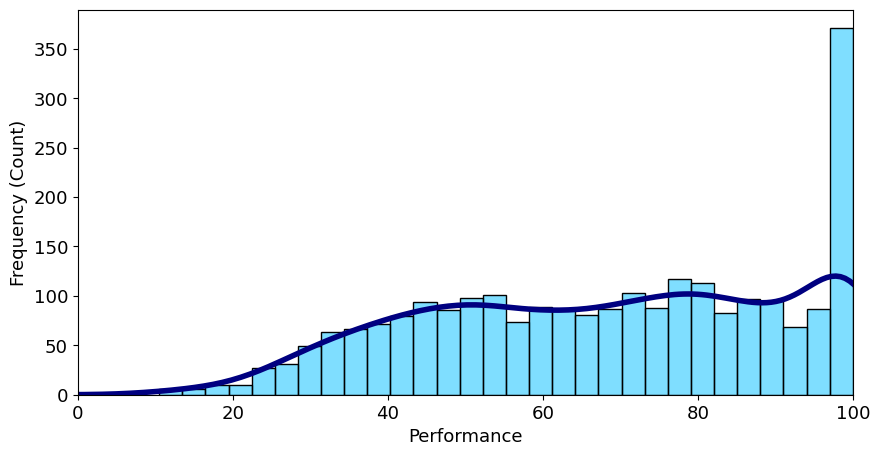

In [10]:
# Histogram graph of Kernel density estimation (KDE) - density function of probability of dependent variable 
# (performance)

plt.figure(figsize=(10,5))

ax = sns.histplot(
    data=period_student_school_df['performance'],
    bins=30,
    color='deepskyblue',
    alpha=0.5)

kde = sns.kdeplot(
    data=period_student_school_df['performance'],
    linewidth=4,
    color='navy')
line = kde.lines[0]
x, y = line.get_data()
bin_width = (period_student_school_df['performance'].max() - 
             period_student_school_df['performance'].min()) / 30
y = y * len(period_student_school_df) * bin_width
line.set_data(x, y)

plt.xlabel('Performance', fontsize=13)
plt.xlim(0, 100)
plt.ylabel('Frequency (Count)', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.show()

<Figure size 1000x500 with 0 Axes>

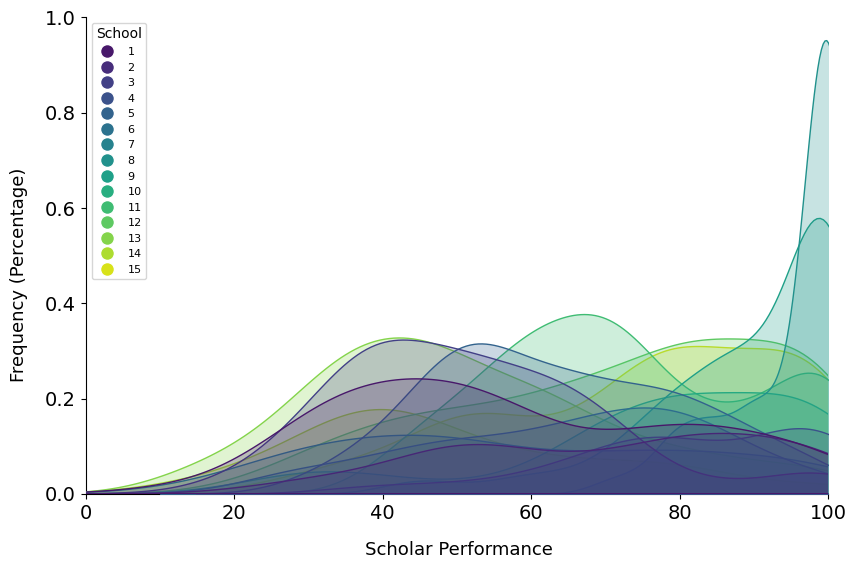

In [11]:
# Plot graph of Kernel density estimation (KDE) - density function of probability of dependent variable 
# (performance) per school

schools = period_student_school_df['school'].unique()
colors = sns.color_palette('viridis', len(schools))

plt.figure(figsize=(10,5))
g = sns.pairplot(period_student_school_df[['school', 'performance']], hue='school',
                 height=5.5,
                 aspect=1.5, palette=colors)
g._legend.remove()
g.set(xlabel=None)
g.set(ylabel=None)
g.tick_params(axis='both', which='major', labelsize=14)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=color,
                              markersize=10, label=school)
                   for school, color in zip(schools, colors)]
plt.legend(handles=legend_elements, title='School', fontsize=8,
           title_fontsize=10)

plt.gcf().text(0.5, -0.01, 'Scholar Performance', ha='center', fontsize=13)
plt.gcf().text(-0.01, 0.5, 'Frequency (Percentage)', va='center', rotation='vertical',
               fontsize=13)
plt.xlim(0, 100)
plt.show()

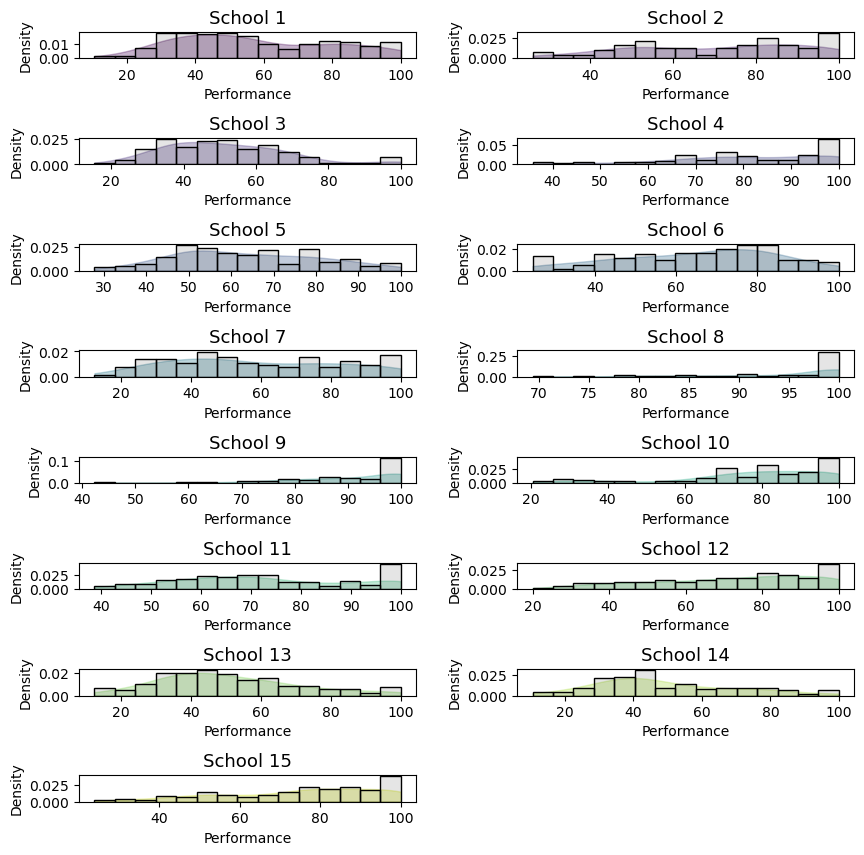

In [12]:
# Histogram graph of Kernel density estimation (KDE) - density function of probability of dependent variable 
# (performance) per school, separately

schools = period_student_school_df['school'].unique()

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(
    len(schools) // 2 + 1,
    2,
    figure=fig,
    hspace=3,
    wspace=0.3
)

for i, school in enumerate(schools):
    ax = fig.add_subplot(gs[i])

    school_df = period_student_school_df[period_student_school_df['school'] == school]

    density = gaussian_kde(school_df['performance'])
    x_vals = np.linspace(min(school_df['performance']),
                         max(school_df['performance']), len(school_df))
    y_vals = density(x_vals)

    ax.fill_between(x_vals, y_vals,
                    color=sns.color_palette('viridis',
                                            as_cmap=True)(i/len(schools)),
                    alpha=0.3)
    
    sns.histplot(school_df['performance'], ax=ax, stat="density", color="black",
                 edgecolor="black", fill=True, 
                 bins=15, alpha=0.1)
    ax.set_title(f'School {school}', fontsize=13)
    ax.set_ylabel('Density')
    ax.set_xlabel('Performance')

plt.show()

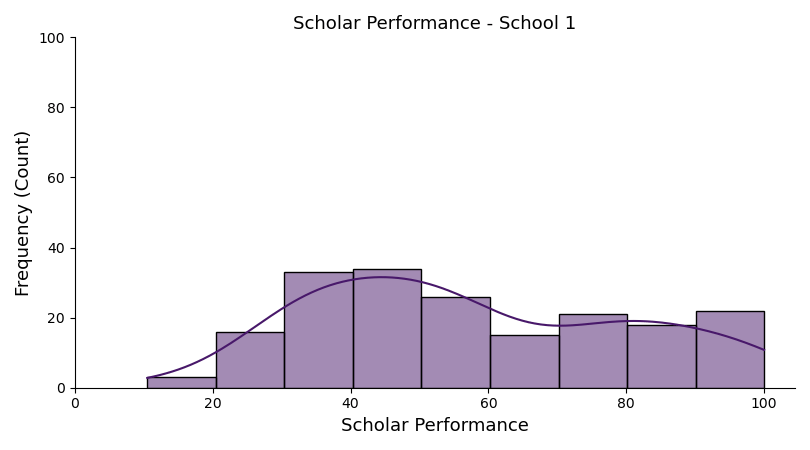

In [13]:
# Histogram graph of Kernel density estimation (KDE) - density function of probability of dependent variable 
# (performance) per school, separately
# Animation on Plots environment

schools = period_student_school_df['school'].unique()

color_numb = len(schools)

school_color = dict(zip(schools, sns.color_palette('viridis', color_numb)))

frames = []

for school in schools:
    data = period_student_school_df[period_student_school_df['school'] == school]

    g = sns.FacetGrid(data, hue='school', palette=[school_color[school]],
                      height=4.5, aspect=1.8)
    g.map(sns.histplot, 'performance', kde=True)
    g.ax.set_title(f"Scholar Performance - School {school}", fontsize=13)
    g.ax.set_xlabel('Scholar Performance', fontsize=13)
    g.ax.set_ylabel('Frequency (Count)', fontsize=13)
    g.ax.tick_params(axis='x', labelsize=10)
    g.ax.tick_params(axis='y', labelsize=10)

    plt.xticks(np.arange(0, 101, 20))
    plt.yticks(np.arange(0, 101, 20))
    plt.tight_layout()

    # converting the graph into a canvas img
    plt_canvas = plt.get_current_fig_manager().canvas
    plt_canvas.draw()
    image = np.asarray(plt_canvas.buffer_rgba())  # RGBA
    image = image[:, :, :3]  # convert to RGB
    # add to the list of gif frames
    frames.append(image)
    # cleans the plt for the next iteration
    plt.close()

# saves all frames as a GIF
imageio.mimsave('graphic_schools_2.gif', frames, fps=1, loop=0)

# shows the gif
display(Image(filename='graphic_schools_2.gif'))

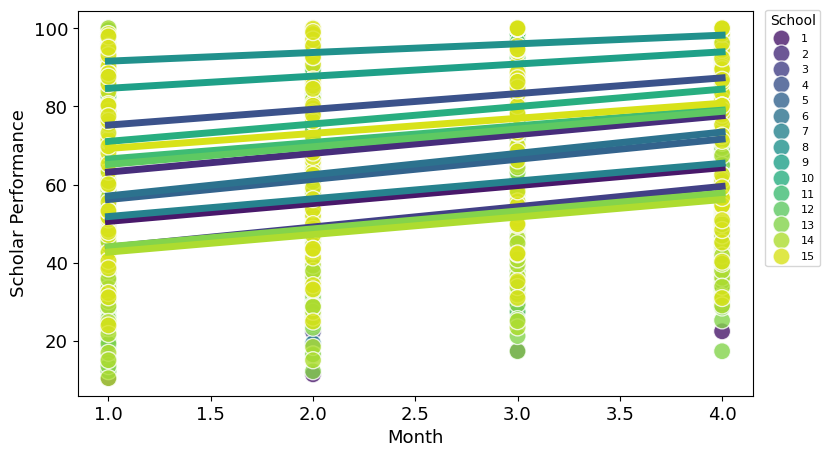

In [14]:
# temporal evolution of mean performance per school (linear adjustment)
# observe that multilevel modeling already treats heteroskedasticity of the data

palette = sns.color_palette('viridis',
                            len(period_student_school_df['school'].unique()))

plt.figure(figsize=(10,5))
sns.scatterplot(data=period_student_school_df, x='month', y='performance', hue='school',
                palette=palette, s=150, alpha=0.8, edgecolor='w')

for school in period_student_school_df['school'].cat.categories:
    subset = period_student_school_df[period_student_school_df['school'] == school]
    sns.regplot(data=subset, x='month', y='performance', scatter=False, ci=False,
                line_kws={"color": palette[period_student_school_df['school'].\
                                           cat.categories.get_loc(school)],
                          'linewidth': 5})

plt.xlabel('Month', fontsize=13)
plt.ylabel('Scholar Performance', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.subplots_adjust(right=0.8)
plt.legend(
    title='School',
    title_fontsize=10,
    fontsize=8,
    loc='center right',
    bbox_to_anchor=(1.1, 0.67),
    frameon=True,
    borderaxespad=0
)
plt.show()

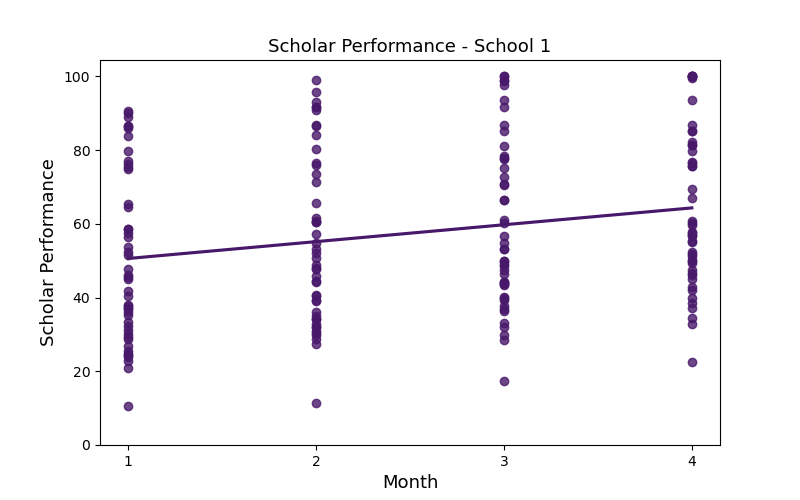

In [15]:
# Histogram graph of Kernel density estimation (KDE) - density function of probability of dependent variable 
# (performance) per month per school, separately
# Animation on Plots environment

schools = period_student_school_df['school'].unique()

color_numb = len(schools)

school_color = dict(zip(schools, sns.color_palette('viridis', color_numb)))

frames = []

for school in schools:
    data = period_student_school_df[period_student_school_df['school'] == school]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.regplot(x='month', y='performance', data=data, color=school_color[school],
                ax=ax, ci=False)
    plt.title(f"Scholar Performance - School {school}", fontsize=13)
    plt.xlabel("Month", fontsize=13)
    plt.ylabel("Scholar Performance", fontsize=13)
    plt.tick_params(axis='x', labelsize=10)
    plt.tick_params(axis='y', labelsize=10)
    plt.yticks(np.arange(0, 101, 20))
    plt.xticks(np.arange(1, 5, 1))
    # converting the graph into a canvas img
    plt_canvas = plt.get_current_fig_manager().canvas
    plt_canvas.draw()
    image = np.asarray(plt_canvas.buffer_rgba())  # RGBA
    image = image[:, :, :3]  # convert to RGB
    # add to the list of gif frames
    frames.append(image)
    # cleans the plt for the next iteration
    plt.close()

# saves all frames as a GIF
imageio.mimsave('graphic_schools_3.gif', frames, fps=1, loop=0)

# shows the gif
display(Image(filename='graphic_schools_3.gif'))

![./null-model-hlm3.png](./null-model-hlm3.png)

![./icc.png](./icc.png)

### **Modeling the null model or random intercept - HLM3 with temporal repeated measures**

Similar to the hlm2 example, available at this same directory, but now using 3 levels. Repeated measures are temporal HLM multilevel regression models where the lowest level (period level) consists of repeated observations (for the same student) over time - in this case 4 times, as the follow-up done was during a 4-month period, for each student. At this null model, the β₀ⱼₖ, i.e., the intercept from level 1 (period - month), is decomposed, at level 2, into a fixed (γ₀₀ₖ) and variable (ν₀ⱼₖ) parts, and the fixed part at level 2, in turn, is decomposed again, at level 3, into another fixed (δ₀₀₀) and variable (τ₀₀ₖ) parts. We thus modelate the random effect of the original level 1 intercept into two other levels. At level 3 or school level, the intercept will vary only between different school classes - cluster or level units, through the τ₀₀ₖ param - it's an inter-class variance. At level 2 or student level, the intercept will vary between different students within each respective school cluster or group, therefore it's an intra-class variance, regarding each school. And at level 1 or period level, the intercept will vary between different periods within each respective student individual - if we consider each student a cluster or group of periods, we thus also have an intra-class variance - but, instead of students within schools, the variance is of periods within each student... or observation tjk. We follow the same step-up approach of the hlm2 example, but now with one level more. Below we initially model the null model - only with the intercept regression expression at each level, for later we improve it with the modeling of the slope and the predictors, as we did on the other example.

In [16]:
# Estimating the null model

hlm3_null_model = sm.MixedLM.from_formula(formula='performance ~ 1',
                                           groups='school',
                                           re_formula='1',
                                           vc_formula={'student': '0 + C(student)'},
                                           data=period_student_school_df).fit()

# formula='performance ~ 1': models, at the level 1, only the intercept (β₀ⱼₖ), with no slope coefficient or 
# predictors - therefore, 1 (constant intercept, with level-1 residual (εₜⱼₖ) - the residual being the intra-class 
# variance, between periods, within each j student (the class) and k school (the other class);

# groups='school': models the highest-level cluster or group - level 3, i.e. "school", both here, as at the hlm2 
# example, available at this same directory;

# re_formula='1': "random effects formula" models the random intercept (τ₀₀ₖ) of the groups level, i.e., level 3 or 
# school's level - inter-class intercept variance, regarding the highest hierarchy class, which is school, i.e., the 
# variance between k schools;

# vc_formula={'student': '0 + C(student)'}: "variance component formula" models the random intercept (ν₀ⱼₖ) of level 
# 2 or student's level - intra-class intercept variance, regarding the variance between j students of each same k 
# school, or inter-class if we consider the variance between students (wich is a class of periods);

hlm3_null_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: performance
No. Observations: 2440    Method:             REML       
No. Groups:       15      Scale:              41.6494    
Min. group size:  80      Log-Likelihood:     -9092.1387 
Max. group size:  248     Converged:          Yes        
Mean group size:  162.7                                  
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      68.714    3.553 19.337 0.000 61.749 75.679
school Var    180.222   11.137                           
student Var   325.798    3.477                           
=========================================================

"""

In [17]:
# "Intercept": it's the level-3 fixed component (δ₀₀₀), the fixed part of the level-1 intercept at level-3 context 
# layer. It is the grand mean of performance across all periods, students and schools. On average, students score 
# about 68.714 points. Estimates the overall average performance. It's value doesn't vary eiher between different tjk
# observations or between different t periods, j students or k schools. It is fixed for all 3 levels (that's why it's 
# subscripted as 000.

# In HLM3, we have 3 variance components, namely the level-3 (school) τ₀₀ₖ, the level-2 (student) ν₀ⱼₖ and the level-1
# (period / repeated measures) εₜⱼₖ. As these values are not fixed for the model as a whole, but vary according the
# specific classes at each observation / prediction, the model above gives us a variance of them around the only fixed
# value (for the whole model) which is the general mean of performance δ₀₀₀. So we do not have one single value for
# the variant part of the intercept regarding each level, but a list of them, with the values depending on the 
# observation or prediction... and a variance towards the fixed mean. The model summary gives us the variances, as 
# below defined (while the individual values we'll calculate later, down below):

# "school Var" is the level-3 inter-class variance - σ²(τ₀₀ₖ) - the variance of the random part of the level-1 
# intercept at level-3 context layer. This is the between-school variance and tells you how much schools differ from 
# each other in their average performance. It varies only between different school classes (level 3), but not between 
# different periods (level 1) or students (level 2) (that's why subscripts t and j are 00). It is influenced by 
# level-3 context (school) variables, e.g. professor_experience_years, but not by other variables, as month - period 
# level - or extra_class_activity - student level.

# "student Var" is the level-2 intra-class / inter-class variance - σ²(ν₀ⱼₖ) - the variance of the random part of the 
# level-1 intercept at level-2 context layer. Both student as school are classes (contexts), as well as month, though
# at different levels. THe current param is the between-student variance (inter-class) within each school class 
# (intra-class), and tells you how much students differ from each other in their average performance, inside one same 
# school. It varies between different students (level 2), at each respective school (level 3), but not between 
# different months (level 1) (that's why subscript t is 0). It is influenced by level-2 context (student) variables, 
# e.g. extra_class_activity, but not by other variables, as month - period level.

# "Scale" is the level-1 residual variance (σ²εₜⱼₖ) — the within student variance of performance after accounting for 
# period differences. It varies between different observations (periods of each student at different schools), 
# including intra-class (within one same student context). I.e., for each student, the variance of their performance 
# across months (periods), after accounting for all higher-level effects.

# Log-Likelihood: like the other regression analysis types, Log-likelihood of the model is used for model comparison 
# (higher = better fit, i.e. less negative = better).

![./icc-hlm3.png](./icc-hlm3.png)

### **Comparing the HLM3 null model above with OLS null model**

In [18]:
# estimating OLS null model
ols_null_model = sm.OLS.from_formula(formula='performance ~ 1',
                                      data=period_student_school_df).fit()

ols_null_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 12 May 2026   Prob (F-statistic):                nan
Time:                        06:19:54   Log-Likelihood:                -11110.
No. Observations:                2440   AIC:                         2.222e+04
Df Residuals:                    2439   BIC:                         2.223e+04
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     68.3414      0.465    146.892      0.000      67.429      69.254
==============================================================================
Omnibus:                      742.376   Durbin-Watson:                   0.440
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              133.934
Skew:                          -0.230   Prob(JB):                     8.25e-30
Kurtosis:                       1.949   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

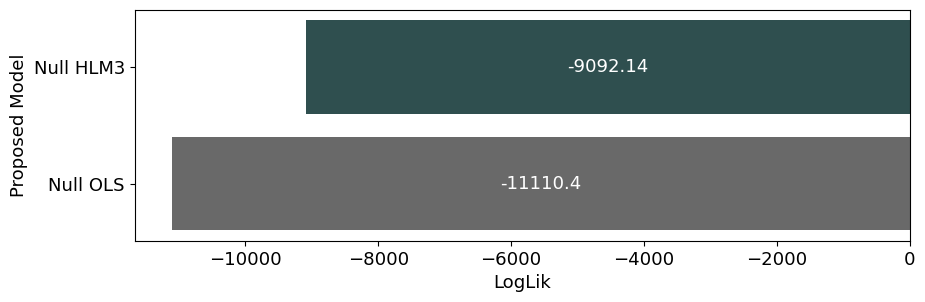

In [19]:
# visually comparing LogLiks for the estimated models so far

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM3'],
                      'loglik':[ols_null_model.llf,hlm3_null_model.llf]})

fig, ax = plt.subplots(figsize=(10,3))

c = ['dimgray','darkslategray']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [20]:
# performing Likelihood Ratio (LR) Test on both models above, for statiscally proving a difference and a statistical
# better model for the one with the highest logLik

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llf
    llk_2 = models[1].llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 2) # 2 degrees of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")

lrtest([ols_null_model, hlm3_null_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 4036.43
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


![./intercept-slope-model-hlm3.png](./intercept-slope-model-hlm3.png)

### **Modeling the random intercept and random slope linear-trend Growth model - HLM3 with temporal repeated measures**

Continuing the step-up approach, we now introduce the level-1 Xₜⱼₖ predictor at the model, namely the monthₜⱼₖ, and therefore its coefficient β₁ⱼₖ . This level-1 β₁ⱼₖ coefficient is explained at levels 2 and 3 as above image expressions - including γ₁ and δ₁ fixed params, and ν₁ and τ₁ variation params. All this in addition to the intercept level-1, level-2 and level-3 params already present at the hlm3 null model. Substituting level-3 expressions on level-2 ones, and level-2 expressions on level-1 main expression, we have the substituted performance expression above (without betas or gamas). The delta terms model the fixed parts of the model, while the epsilon, ni and tau terms model the variant parts of the same model, regarding both the intercept and the slope. This is not the final model yet, as we have not added the other two predictor variables - W and Z (or its coefficients) so far. We'll do this on the next model - similar to our approach at the hlm2 example, available at this same directory.

In [21]:
# estimating the linear-trend Growth model with random intercept and random slope HLM-3 - only with the level-1 
# predictor (month)

intercept_slope_hlm3_model = sm.MixedLM.from_formula(formula='performance ~ month',
                                                       groups='school',
                                                       re_formula='1+month',
                                                       vc_formula={'student': '0 + C(student)'},
                                                       data=period_student_school_df).fit()

# re_formula='1 + month' -> random intercepts and slopes per school - each school with its own regression line
intercept_slope_hlm3_model.summary()

# it may take a while until it converges, and some failures might happen before that... just wait around 5 min 
# up until it finally outputs some model as a result - the kernel keeps trying until it finally gets it

/home/daniel/anaconda-workspace/sample-ml-multilevel-regression-analysis/env/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/anaconda-workspace/sample-ml-multilevel-regression-analysis/env/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/daniel/anaconda-workspace/sample-ml-multilevel-regression-analysis/env/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/anaconda-workspace/sample-ml-multilevel-regression-analysis/env/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying Mix

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:               MixedLM  Dependent Variable:  performance
No. Observations:    2440     Method:              REML       
No. Groups:          15       Scale:               8.6904     
Min. group size:     80       Log-Likelihood:      -7744.5449 
Max. group size:     248      Converged:           No         
Mean group size:     162.7                                    
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           57.836    2.986 19.368 0.000 51.983 63.688
month                4.343    0.292 14.886 0.000  3.771  4.915
school Var         122.116   11.189                           
school x month Cov  -3.007    0.904                           
month Var            1.230                                    
student Var        415.053   12.204                           
==============================================================

"""

In [22]:
# "Intercept": it's the level-3 fixed component (δ₀₀₀) regarding the intercept.

# "school Var" is the level-3 inter-class variance (between schools) - σ²(τ₀₀ₖ) - regarding the intercept.

# "student Var" is the level-2 intra-class / inter-class variance (between students inside each school) - σ²(ν₀ⱼₖ) - 
# regarding the intercept.

# "Scale" is the level-1 residual variance (σ²εₜⱼₖ).

# Log-Likelihood: like the other regression analysis types, Log-likelihood of the model is used for model comparison 
# (higher = better fit, i.e. less negative = better).

# All above with same definition as last model.
# New outputs:

# "month" is the level-3 fixed component - δ₁₀₀ - regarding the slope.

# "month Var" is the level-3 inter-class variance (between schools) - σ²(τ₁₀ₖ) - regarding the slope.

# Limitations of this API:
# level-2 variation regarding the slope (between students inside each school) - σ²(ν₁ⱼₖ) - exists but it is not 
# identifiable through the statsmodels MixedLM method:
# statsmodels.MixedLM doesn't truly support 3-level models. MixedLM is designed for 2-level models. The vc_formula 
# trick for the third level is a workaround, not a native 3-level implementation. It often causes convergence issues 
# for complex random effects structures. Switch to lme4 in R — it handles true HLM-3 natively and is far more stable 
# for this kind of model (lmer(performance ~ month + (1 + month | school/student))). Or use pymer4 in Python, which 
# wraps lme4 via rpy2. Another option is to use method="lbfgs" or method="powell" inside the fit method, as 
# .fit(method="lbfgs") or .fit(method="powell"). Changing the internal convergence method will change slightly the
# values of the LogLiks.

# statsmodels MixedLM with the vc_formula workaround for Level 3 cannot separately estimate ν₁ⱼₖ (the random slope 
# variance at Level 2). The student Var only captures ν₀ⱼₖ. The random slope at Level 2 is simply not identified in 
# this implementation — which is another reason to consider lme4/pymer4, which would give you separate variance 
# components for both ν₀ⱼₖ and ν₁ⱼₖ.

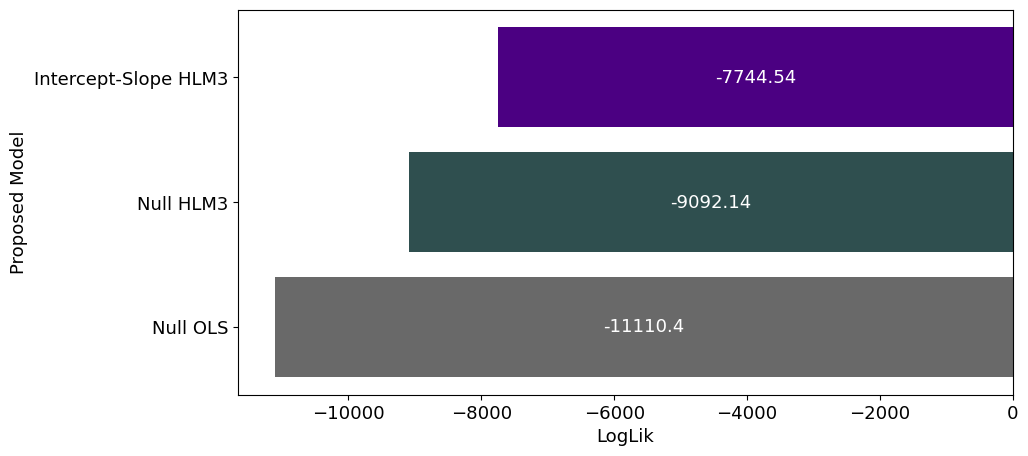

In [23]:
# visually comparing LogLiks of so far estimated models

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM3',
                                 'Intercept-Slope HLM3'],
                      'loglik':[ols_null_model.llf,hlm3_null_model.llf,
                                intercept_slope_hlm3_model.llf]})

fig, ax = plt.subplots(figsize=(10,5))

c = ['dimgray','darkslategray','indigo']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [24]:
# LLR test between the last two models
lrtest([hlm3_null_model, intercept_slope_hlm3_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 2695.19
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [25]:
# so, the superior model so far ir the intercept_slope_hlm3_model, with a statistic different and higher LogLikelihood
# when compared to the hlm3_null_model (which we have already tested as superior to the OLS null model).

![./intercept-slope-model-final-hlm3.png](./intercept-slope-model-final-hlm3.png)

### **Modeling the Random Intercept and Random Slope Linear-Trend Final Model - HLM3 with temporal repeated measures**

In this last stage of the step up approach, we model the final model by adding the other two predictors: level-2 extra_class_activity and level-3 professor_experience_years, as well as their respective coefficients γ₁₁ₖ and δ₁₀₁. We also add the δ₁₁₀ at level-3 for explaining the level-2 γ₁₁ₖ. Observe that, at the final formula, we only have the deltas (as fixed components); epsilon, nis and taus (as variant components); and the three predictive variables, from the three levels.

In [26]:
# for introducing the extra_class_activity qualitative 2-level variable at the model, we gotta proceed its dumyzation
# first

period_student_school_dummies_df = pd.get_dummies(period_student_school_df, columns=['extra_class_activity'],
                                       dtype=int,
                                       drop_first=True)

period_student_school_dummies_df

,school,student,month,performance,professor_experience_years,extra_class_activity_yes
0,1,1,1,35.400002,2,0
1,1,1,2,44.400002,2,0
2,1,1,3,46.400002,2,0
3,1,1,4,52.400002,2,0
4,1,2,1,74.900002,2,0
...,...,...,...,...,...,...
2435,15,609,4,100.000000,9,1
2436,15,610,1,87.599998,9,1
2437,15,610,2,92.599998,9,1
2438,15,610,3,94.599998,9,1


In [27]:
# estimating the linear-trend Final model with random intercept and random slope HLM-3 - with all-level predictors

intercept_slope_hlm3_final_model = sm.MixedLM.from_formula(formula='performance ~ month +\
                                            extra_class_activity_yes:month + professor_experience_years:month',
                                            groups='school',
                                            re_formula='1 + month',
                                            vc_formula={'student': '0 + C(student)'},
                                            data=period_student_school_dummies_df).fit()

# observe above that we now add extra_class_activity_yes and professor_experience_years as nested predictors relative
# to the level-1 predictor which is month. This means that, at the formula (picture above) these two nested predictors
# will appear multiplying month (nested to it).
intercept_slope_hlm3_final_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:                   MixedLM       Dependent Variable:       performance
No. Observations:        2440          Method:                   REML       
No. Groups:              15            Scale:                    9.1418     
Min. group size:         80            Log-Likelihood:           -7726.6779 
Max. group size:         248           Converged:                Yes        
Mean group size:         162.7                                              
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         57.845    3.966 14.584 0.000 50.071 65.619
month                              4.680    0.282 16.566 0.000  4.126  5.233
extra_class_activity_yes:month    -0.432    0.126 -3.429 0.001 -0.678 -0.185
professor_experience_years:month  -0.012    0.025 -0.487 0.626 -0.061  0.037
school Var                       226.348   29.610                           
school x month Cov                -7.903    1.405                           
month Var                          0.453    0.080                           
student Var                      339.259    7.581                           
============================================================================

"""

In [28]:
# as we can see at the model summary above, professor_experience_years:month did not pass the validation, as its
# p-value was not significant for a 95% confidence level (>0.05). As there's no stepwise to fix the formula, only
# with significant predictors, we can manually take this component out by changing the sm.MixedLM input expression to:

intercept_slope_hlm3_final_model = sm.MixedLM.from_formula(formula='performance ~ month +\
                                            extra_class_activity_yes:month + professor_experience_years',
                                            groups='school',
                                            re_formula='1 + month',
                                            vc_formula={'student': '0 + C(student)'},
                                            data=period_student_school_dummies_df).fit()

# at the method input experssion above, we adapted the final model by adding professor_experience_years as a level-3
# predictor modeling the intercept, instead of the slope - see below image.
intercept_slope_hlm3_final_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
==========================================================================
Model:                   MixedLM      Dependent Variable:      performance
No. Observations:        2440         Method:                  REML       
No. Groups:              15           Scale:                   9.1400     
Min. group size:         80           Log-Likelihood:          -7721.9483 
Max. group size:         248          Converged:               Yes        
Mean group size:         162.7                                            
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       51.402    4.377 11.744 0.000 42.823 59.980
month                            4.588    0.206 22.297 0.000  4.185  4.992
extra_class_activity_yes:month  -0.454    0.127 -3.583 0.000 -0.702 -0.206
professor_experience_years       0.785    0.383  2.046 0.041  0.033  1.536
school Var                     130.189   20.517                           
school x month Cov              -6.044    1.073                           
month Var                        0.511    0.071                           
student Var                    339.711    7.593                           
==========================================================================

"""

In [29]:
# "Intercept": it's the level-3 fixed component (δ₀₀₀) regarding the intercept.

# "school Var" is the level-3 inter-class variance (between schools) - σ²(τ₀₀ₖ) - regarding the intercept.

# "student Var" is the level-2 intra-class / inter-class variance (between students inside each school) - σ²(ν₀ⱼₖ) - 
# regarding the intercept.

# "Scale" is the level-1 residual variance (σ²εₜⱼₖ).

# "month" is the level-3 fixed component - δ₁₀₀ - regarding the slope.

# "month Var" is the level-3 inter-class variance (between schools) - σ²(τ₁₀ₖ) - regarding the slope.

# Log-Likelihood: like the other regression analysis types, Log-likelihood of the model is used for model comparison 
# (higher = better fit, i.e. less negative = better).

# All above with same definition as last model.
# New outputs:

# "extra_class_activity_yes:month" is the level-3 fixed component δ₁₁₀ that explains the level-2 coefficient γ₁₁ₖ of 
# the predictor extra_class_activity_yes - regarding the slope. It measures how the extra_class_activity_yes predictor
# influences the slope (performance increase rate) between different schools.

# "professor_experience_years" is the level-3 fixed component δ₀₀₁ of the predictor professor_experience_years - 
# regarding the intercept. In the prior model it was used to exmplain the slope, but was statistically not significant, 
# so we changed it to explaining the intercept, instead. It measures how the professor_experience_years predictor 
# influences the intercept (starting point of the regression line) between different schools.

# Limitation:
# observe there's no output for the σ²(ν₁ⱼₖ), the variant part of the slope at level-2, as we have already discussed 
# above as a limitation of such API.

In [30]:
# regarding the formula, what we just did, by not using professor_experience_years:month at the model defining 
# expression, but only professor_experience_years, was to keep the professor_experience_years as a level-3 predictor
# at the model, but, instead of it modeling the slope (γ₁₀ₖ), have it modeling the intercept (γ₀₀ₖ), not multiplying
# to month anymore, and changing its coefficient to δ₀₀₁. So the we ended up with the model below. As we saw at the
# model output, all model terms are now statistically significant (p-value < 0.05).

![./intercept-slope-model-final-hlm3-adapted.png](./intercept-slope-model-final-hlm3-adapted.png)

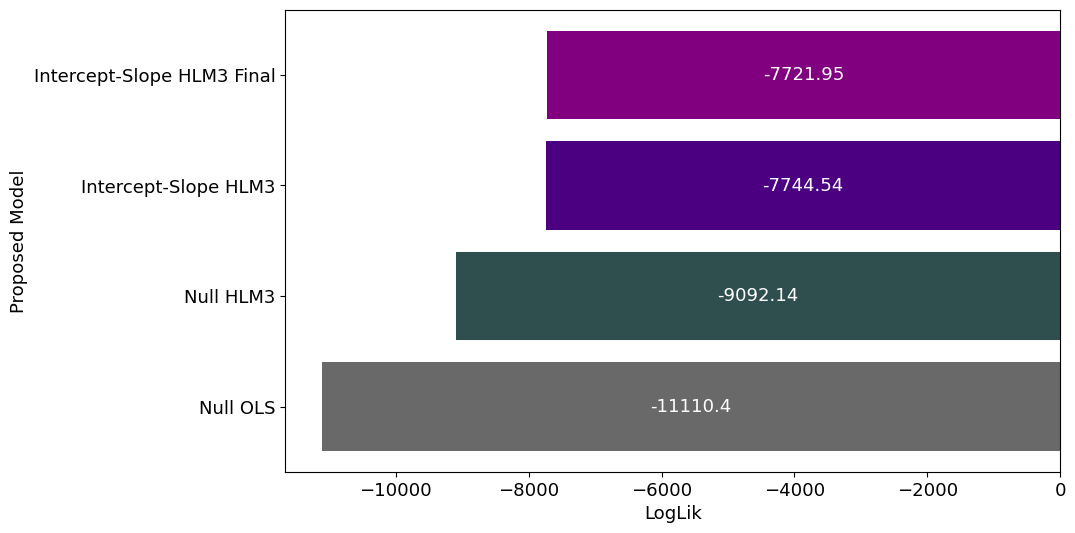

In [31]:
# comparing the LongLiks of models estimated so far

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM3',
                                 'Intercept-Slope HLM3',
                                 'Intercept-Slope HLM3 Final'],
                      'loglik':[ols_null_model.llf,hlm3_null_model.llf,
                                intercept_slope_hlm3_model.llf,
                                intercept_slope_hlm3_final_model.llf]})

fig, ax = plt.subplots(figsize=(10,6))

c = ['dimgray','darkslategray','indigo','purple']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [32]:
# LLR test between models intercept_slope_hlm3_model and intercept_slope_hlm3_final_model
lrtest([intercept_slope_hlm3_model, intercept_slope_hlm3_final_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 45.19
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [33]:
# through the LLR test above, we proved the last final model is significant better than the previous intercept + slope 
# one.

### **Extracting all variant coefficients from upper levels (student and school)**

In [34]:
# Visualizing random intercepts and slopes for intercept_slope_hlm3_final_model

# By student (level-2):
# values of ν₀ⱼₖ (random effects of intercept on level-2 - student) - how intercept varies between students at each
# same school
# As previously commented, the random effects of slope on level-2 - student (ν₁ⱼₖ) are not calculated at this API

# Observe that we have 610 students with a particular ν₀ⱼₖ. As ν₀ⱼₖ is a level-2 student specific variant coefficient 
# (of the intercept), each ν₀ⱼₖ is the same for all four months of period of that student. It only varies according to 
# student (j) and school (k), 'cause if you change school you also change the students.

random_effects = pd.DataFrame(intercept_slope_hlm3_final_model.random_effects).T
random_student = random_effects.T
random_student = random_student.iloc[2:]
random_student = random_student.replace(0, np.nan).stack().reset_index(drop=True)
random_student = random_student.to_frame(name='v0jk').dropna()
random_student = random_student.reset_index(drop=True)
random_student.insert(0, 'student', range(1, len(random_student) + 1))
random_student

,student,v0jk
0,1,-13.720492
1,2,18.562364
2,3,36.451505
3,4,-2.362419
4,5,31.907071
...,...,...
605,606,-25.655563
606,607,9.507919
607,608,-3.504562
608,609,14.682581


In [35]:
# By school (level-3):
# values of τ₀₀ₖ and τ₁₀ₖ (random effects of intercept and slope on level-3 - school) - how intercept and slope varies 
# between different schools
# For level 3, differently from level 2, the API does calculate all variant coefficients (τ₀₀ₖ and τ₁₀ₖ) for both the
# intercept as for the slope, respectively.

# Observe that, here, the taus only vary according to each school (k), not with each student (j) or month (t). So, as
# we have 15 schools, we have, for the whole sample, 15 τ₀₀ₖ and 15 τ₁₀ₖ.

random_effects = pd.DataFrame(intercept_slope_hlm3_final_model.random_effects).T
random_school = random_effects.rename(columns = {'school':'t00k', 'month':'t10k'})
random_school = random_school[['t00k','t10k']]
random_school = random_school.reset_index().rename(columns={'index': 'school'})
random_school

,school,t00k,t10k
0,1,-6.439336,0.184110
1,2,3.952305,0.329753
2,3,-13.521334,0.733579
3,4,10.554485,-0.194623
4,5,-7.210924,0.527686
5,6,-2.492079,0.944708
6,7,-5.098648,0.196236
7,8,21.684162,-1.750537
8,9,14.084184,-1.098841
9,10,11.860016,-0.037439


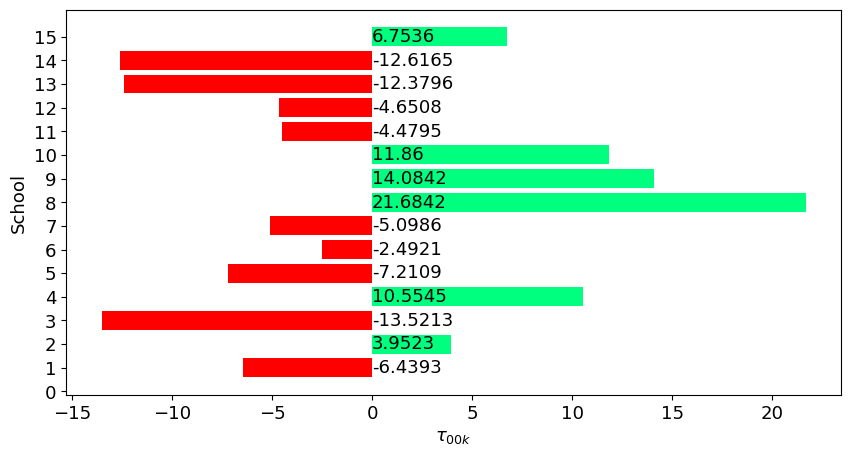

In [36]:
# Plot graph for visualizing the behavior of τ₀₀ₖ , i.e., the random effects on intercept between schools (level 3)
# What we have as the "school Var" output of the intercept_slope_hlm3_final_model, is actually the variance of such
# values - σ²(τ₀₀ₖ) - not exactly, see below.

colors = ['springgreen' if x > 0 else 'red' for x in random_school['t00k']]

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(0, point['y'], str(round(point['x'], 4)), fontsize=13,
                verticalalignment='center')

plt.figure(figsize=(10, 5))
plt.barh(random_school['school'], random_school['t00k'], color=colors)

label_point(x=random_school['t00k'],
            y=random_school['school'],
            val=random_school['t00k'],
            ax=plt.gca()) 

plt.ylabel('School', fontsize=13)
plt.xlabel('$\\tau_{00k}$', fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 16, 1))
plt.show()

The variance calculated from the school random effects does not match `school Var = 130.189` because those values are BLUPs (empirical Bayes estimates / conditional random effects), not the actual variance component estimated by the mixed model. In HLM/GLMM, `school Var` represents the latent population variance parameter τ₀₀ = Var(u₀ₖ), estimated globally by REML using all observations. The estimated school effects û₀ₖ are partially shrunk toward zero to reduce estimation noise, so the variance of the BLUPs is usually smaller than the model-estimated variance component. Therefore, `Var(û₀ₖ)` is not expected to equal `school Var`.

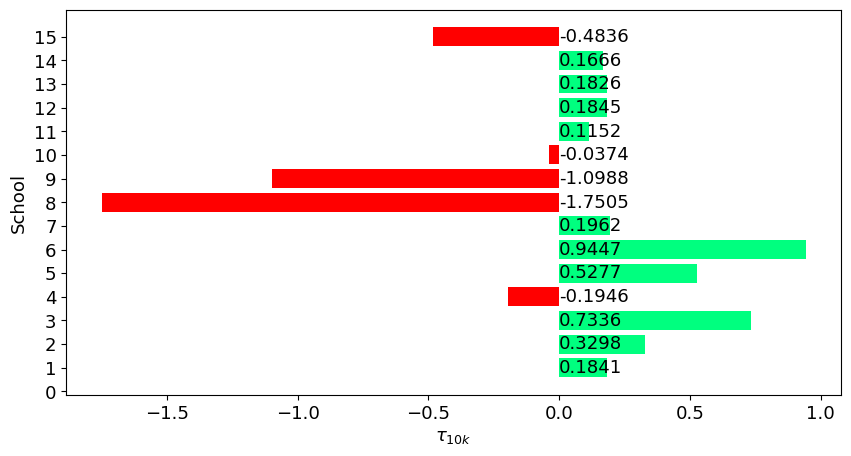

In [37]:
# Plot graph for visualizing the behavior of τ₁₀ₖ , i.e., the random effects on slope between schools (level 3)
# What we have as the "month Var" output of the intercept_slope_hlm3_final_model, is actually the variance of such
# values - σ²(τ₁₀ₖ) - not exactly, see below.

colors = ['springgreen' if x > 0 else 'red' for x in random_school['t10k']]

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(0, point['y'], str(round(point['x'], 4)), fontsize=13,
                verticalalignment='center')

plt.figure(figsize=(10, 5))
plt.barh(random_school['school'], random_school['t10k'], color=colors)

label_point(x=random_school['t10k'],
            y=random_school['school'],
            val=random_school['t10k'],
            ax=plt.gca()) 

plt.ylabel('School', fontsize=13)
plt.xlabel('$\\tau_{10k}$', fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 16, 1))
plt.show()

The same principle applies to τ₁₀ₖ. The model-estimated `month Var = 0.511` represents the population variance component of the random slopes, i.e., τ₁₁ = Var(u₁ₖ), estimated globally by REML. The plotted values are the school-specific random slope estimates û₁ₖ (BLUPs), not the variance parameter itself. Because BLUPs are shrinkage estimates conditioned on the observed data, their empirical variance is not expected to equal the reported `month Var`. Their spread is typically smaller due to partial pooling toward the overall mean slope.

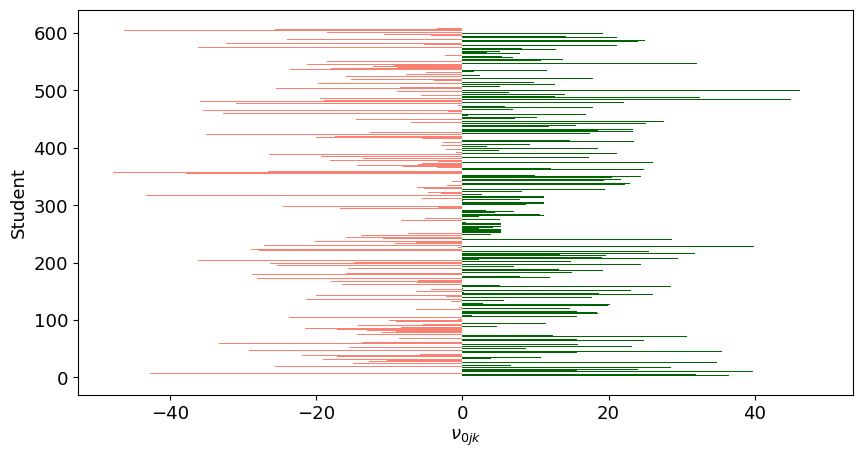

In [38]:
# Plot graph for visualizing the behavior of ν₀ⱼₖ , i.e., the random effects on intercept between students and schools 
# (level 2)
# What we have as the "student Var" output of the intercept_slope_hlm3_final_model, is actually the variance of such
# values - σ²(ν₀ⱼₖ) - not exactly, see below.

colors = ['darkgreen' if x > 0 else 'salmon' for x in random_student['v0jk']]

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(0, point['y'], str(round(point['x'], 4)), fontsize=13,
                verticalalignment='center')

plt.figure(figsize=(10,5))
plt.barh(random_student['student'], random_student['v0jk'], color=colors)
plt.ylabel('Student', fontsize=13)
plt.xlabel(r'$\nu_{0jk}$', fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.yticks()
plt.show()

The variance calculated from the student random effects does not match `student Var = 339.711` because the extracted values are estimated student-specific random effects (BLUPs/conditional modes), not the actual variance parameter estimated by the mixed model. In HLM/GLMM, `student Var` represents the latent population variance component Var(ν₀ⱼₖ), estimated globally by REML using all observations. The individual student effects ν̂₀ⱼₖ are empirical Bayes estimates that are partially shrunk toward zero to reduce estimation noise and improve stability, especially when information per student is limited. As a result, the observed variance of the estimated student random effects is typically smaller than the true latent variance component reported by the model, so the variance of the extracted student effects is not expected to equal the model’s reported `student Var`.

### **Comparing the observed performance values with the model fitted values and residuals**

In [41]:
# adding intercept_slope_hlm3_final_model fitted values and residuals to dataset df
period_student_school_df['fitted_complete'] = intercept_slope_hlm3_final_model.fittedvalues
period_student_school_df['etjk'] = intercept_slope_hlm3_final_model.resid
period_student_school_df

,school,student,month,performance,extra_class_activity,professor_experience_years,fitted_complete,etjk
0,1,1,1,35.400002,no,2,37.583442,-2.183441
1,1,1,2,44.400002,no,2,42.356007,2.043994
2,1,1,3,46.400002,no,2,47.128572,-0.728570
3,1,1,4,52.400002,no,2,51.901136,0.498865
4,1,2,1,74.900002,no,2,69.866299,5.033702
...,...,...,...,...,...,...,...,...
2435,15,609,4,100.000000,yes,9,94.502846,5.497154
2436,15,610,1,87.599998,yes,9,88.094068,-0.494069
2437,15,610,2,92.599998,yes,9,91.745138,0.854861
2438,15,610,3,94.599998,yes,9,95.396208,-0.796209


In [44]:
# comparing the model fitted values with the observed (actual) sample performance values, with the fitted values 
# already including all levels random effects for intercept and slope (both at student-level as at school-level)
effects_df = period_student_school_df[['school','student','month','performance',
                                    'fitted_complete','etjk']]
effects_df

,school,student,month,performance,fitted_complete,etjk
0,1,1,1,35.400002,37.583442,-2.183441
1,1,1,2,44.400002,42.356007,2.043994
2,1,1,3,46.400002,47.128572,-0.728570
3,1,1,4,52.400002,51.901136,0.498865
4,1,2,1,74.900002,69.866299,5.033702
...,...,...,...,...,...,...
2435,15,609,4,100.000000,94.502846,5.497154
2436,15,610,1,87.599998,88.094068,-0.494069
2437,15,610,2,92.599998,91.745138,0.854861
2438,15,610,3,94.599998,95.396208,-0.796209


### **Doing some predictions with the final model**

In [55]:
# manual elabobration of predictions using the intercept_slope_hlm3_final_model

# Ex.: What's the predicted value for school performance on first month ('month' = 1) for the student '1' of 
# school '1', knowing that this student has not participated in extra-class activities and that the school offers
# an average of professor experience of about 2 years ?

# As already commented on the HLM2 project, the result for the predict() method, at this API, only considers
# fixed effects (constants and deltas). We have to add the random effects (nis and taus) manually later.

fixed_result = intercept_slope_hlm3_final_model.predict(pd.DataFrame({'school':[1],
                                                         'student':[1],
                                                         'month':[1],
                                                         'extra_class_activity_yes':[0],
                                                         'professor_experience_years':[2]}))
print(f"The fixed predicted value for school performance is {round(fixed_result[0],2)}, not taking into account the random effects from upper levels (level 2 and level 3) on such student performance, at this school.")

The fixed predicted value for school performance is 57.56, not taking into account the random effects from upper levels (level 2 and level 3) on such student performance, at this school.


In [60]:
# manually adding the random effects on intercept and slope from student and school levels (levels 2 and 3)
# calculating full prediction with both fixed and random effects for student 1 at school 1
# Also, as previously commented, the used API doesn't calculate the random effect on the slope at level 2 (only on 
# the intercept), so we're disregarding it. If another API does calculate it, it could be added, as well, below.

complete_result = fixed_result + random_student['v0jk'][0] +\
    random_school['t00k'][0] + random_school['t10k'][0]*1

print(f"The final and full predicted value for school performance is {round(complete_result[0],2)}, taking into account the random effects from upper levels (level 2 and level 3) on such student performance, at this school.")

The final and full predicted value for school performance is 37.58, taking into account the random effects from upper levels (level 2 and level 3) on such student performance, at this school.


In [63]:
# both the fixed as complete results above are calculated from the final regresion formula of the model, only 
# considering constants and delta fixed terms on the first case, and, on the latter, the random effect variant terms.
# Only the ν₁ⱼₖ·monthₜⱼₖ has been disregarded as the API doesn't calculate ν₁ⱼₖ. Also, the εₜⱼₖ is not part of the
# prediction, and should not be added, because epsilon represents unexplained observation-level variability, which is 
# stochastic noise, not a deterministic component to be added during prediction. εₜⱼₖ is part of the observed value 
# and not of its respective predicted value.

# intercept_slope_hlm3_final_model multilevel regression formula:

# performanceₜⱼₖ = δ₀₀₀ + δ₀₀₁·professor_experience_yearsₖ + δ₁₀₀·monthₜⱼₖ + δ₁₁₀·extra_class_activityⱼₖ·monthₜⱼₖ + 
# ν₀ⱼₖ + ν₁ⱼₖ·monthₜⱼₖ + τ₀₀ₖ + τ₁₀ₖ·monthₜⱼₖ + εₜⱼₖ

### **Final graph visualization and comparison with OLS with dummies**

<Figure size 800x500 with 0 Axes>

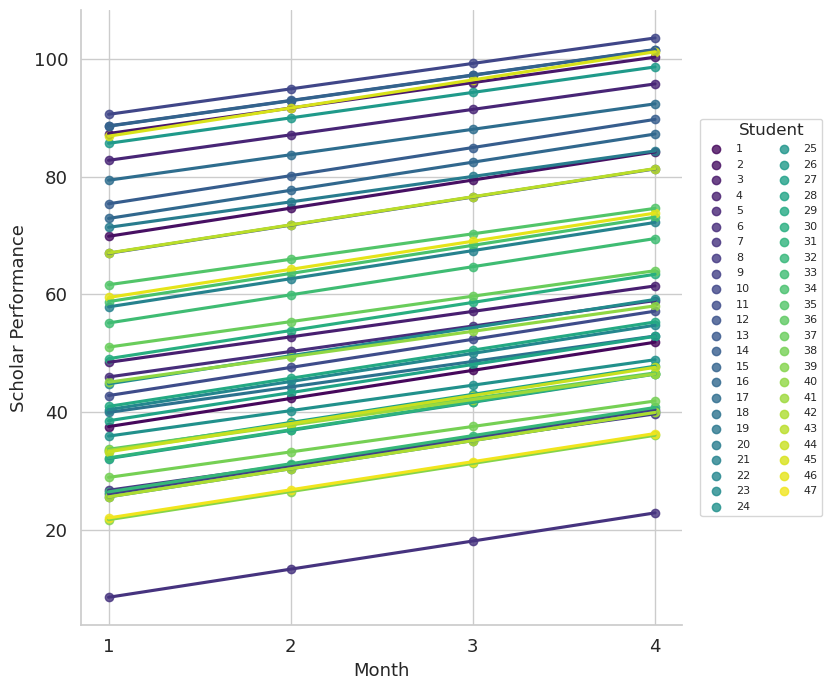

In [73]:
# Plot graph with predicted values of scholar performance along time for the 47 first students of our sample that
# are matriculated at school 1. Observe we have a time-series of only 4 months, but it could be a much longer period.

period_student_school_df['student'] = period_student_school_df['student'].astype('int')
df = period_student_school_df[period_student_school_df['student'] <= 47]
period_student_school_df['student'] = period_student_school_df['student'].astype('category')

plt.figure(figsize=(8, 5))
sns.set(style='whitegrid')
g = sns.lmplot(x='month', y='fitted_complete', data=df, hue='student',
           ci=False, height=7, palette='viridis')
g._legend.remove()
g.set(xlabel=None)
g.set(ylabel=None)
plt.ylabel('Scholar Performance', fontsize=13)
plt.xlabel('Month', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.xticks(np.arange(1, 5, 1))
legend = plt.legend(title='Student', fontsize=8, title_fontsize=12, ncol=2,
                    loc='center left', bbox_to_anchor=(1.03, 0.5), borderaxespad=0.)
legend.get_title().set_position((10, 0))
plt.show()

In [78]:
# Comparing the multilevel GLMM HLM3 final model above with a correspondent OLS model with dummies, in terms of
# predictability

# creating n-1 dummies for schools
dummyzed_dataset = pd.get_dummies(period_student_school_df[['school',
                                                       'student',
                                                       'month',
                                                       'performance',
                                                       'professor_experience_years',
                                                       'extra_class_activity']],
                                    columns=['school'],
                                    dtype=int,
                                    drop_first=True)
dummyzed_dataset

,student,month,performance,professor_experience_years,extra_class_activity,school_2,school_3,school_4,school_5,school_6,school_7,school_8,school_9,school_10,school_11,school_12,school_13,school_14,school_15
0,1,1,35.400002,2,no,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,2,44.400002,2,no,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,3,46.400002,2,no,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,4,52.400002,2,no,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2,1,74.900002,2,no,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,609,4,100.000000,9,yes,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2436,610,1,87.599998,9,yes,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2437,610,2,92.599998,9,yes,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2438,610,3,94.599998,9,yes,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [80]:
# estimating an OLS model with the same variables as the HLM3 final model

# creating multiplicative variables and definition of the regresssion expression to be used as input at the model 
# definition

dummyzed_dataset['extra_class_activity_month'] = dummyzed_dataset['extra_class_activity'] * dummyzed_dataset['month']
dummyzed_dataset['professor_experience_years_month'] = dummyzed_dataset['professor_experience_years'] * dummyzed_dataset['month']

column_list = list(dummyzed_dataset.drop(columns=['student',
                                                  'performance',
                                                  'professor_experience_years',
                                                  'extra_class_activity']).columns)
ols_model_dummies_formula = ' + '.join(column_list)
ols_model_dummies_formula = "performance ~ " + ols_model_dummies_formula
ols_model_dummies_formula

'performance ~ month + school_2 + school_3 + school_4 + school_5 + school_6 + school_7 + school_8 + school_9 + school_10 + school_11 + school_12 + school_13 + school_14 + school_15 + extra_class_activity_month + professor_experience_years_month'

In [82]:
# estimating the OLS with dummies model

ols_dummies_model = sm.OLS.from_formula(ols_model_dummies_formula,
                                         dummyzed_dataset).fit()

ols_dummies_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     80.25
Date:                Tue, 12 May 2026   Prob (F-statistic):          5.39e-268
Time:                        08:14:01   Log-Likelihood:                -10441.
No. Observations:                2440   AIC:                         2.093e+04
Df Residuals:                    2417   BIC:                         2.106e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     35.7368      1.930     18.512      0.000      31.951      39.522
extra_class_activity_month[T.nono]            -3.3843      1.229     -2.755      0.006      -5.793      -0.975
extra_class_activity_month[T.nonono]          -7.1860      1.025     -7.011      0.000      -9.196      -5.176
extra_class_activity_month[T.nononono]       -10.9996      0.907    -12.121      0.000     -12.779      -9.220
extra_class_activity_month[T.yes]             14.0173      1.529      9.170      0.000      11.020      17.015
extra_class_activity_month[T.yesyes]          10.0506      1.221      8.232      0.000       7.657      12.445
extra_class_activity_month[T.yesyesyes]        5.5767      0.989      5.639      0.000       3.637       7.516
extra_class_activity_month[T.yesyesyesyes]     0.8854      0.894      0.990      0.322      -0.868       2.639
month                                          8.8421      0.523     16.902      0.000       7.816       9.868
school_2                                      10.9074      2.176      5.012      0.000       6.640      15.175
school_3                                      -5.0591      1.801     -2.809      0.005      -8.591      -1.527
school_4                                      16.8711      2.515      6.708      0.000      11.939      21.803
school_5                                      12.5500      1.986      6.320      0.000       8.656      16.444
school_6                                       4.8177      2.060      2.339      0.019       0.779       8.857
school_7                                      -0.5401      2.098     -0.257      0.797      -4.654       3.573
school_8                                      31.8166      2.821     11.279      0.000      26.285      37.348
school_9                                      30.6534      2.702     11.345      0.000      25.355      35.952
school_10                                     20.0053      1.993     10.038      0.000      16.097      23.913
school_11                                      9.8348      2.666      3.689      0.000       4.607      15.063
school_12                                     14.5099      2.439      5.949      0.000       9.727      19.293
school_13                                     -6.1578      1.758     -3.502      0.000      -9.606      -2.710
school_14                                     -8.0338      2.119     -3.791      0.000     -12.189      -3.879
school_15                                     17.2718      1.919      9.002      0.000      13.510      21.034
professor_experience_years_month              -0.0478      0.044     -1.094      0.274      -0.133       0.038
==============================================================================
Omnibus

In [83]:
# performing stepwise on ols_dummies_model
ols_dummies_step_model = stepwise(ols_dummies_model, pvalue_limit=0.05)
ols_dummies_step_model.summary()

Regression type: OLS 

Estimating model...: 
 performance ~ Q('extra_class_activity_month[T.nono]') + Q('extra_class_activity_month[T.nonono]') + Q('extra_class_activity_month[T.nononono]') + Q('extra_class_activity_month[T.yes]') + Q('extra_class_activity_month[T.yesyes]') + Q('extra_class_activity_month[T.yesyesyes]') + Q('extra_class_activity_month[T.yesyesyesyes]') + Q('month') + Q('school_2') + Q('school_3') + Q('school_4') + Q('school_5') + Q('school_6') + Q('school_7') + Q('school_8') + Q('school_9') + Q('school_10') + Q('school_11') + Q('school_12') + Q('school_13') + Q('school_14') + Q('school_15') + Q('professor_experience_years_month')

 Discarding atribute "Q('school_7')" with p-value equal to 0.7968401390907668 

Estimating model...: 
 performance ~ Q('extra_class_activity_month[T.nono]') + Q('extra_class_activity_month[T.nonono]') + Q('extra_class_activity_month[T.nononono]') + Q('extra_class_activity_month[T.yes]') + Q('extra_class_activity_month[T.yesyes]') + Q('extra_c

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     88.24
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.14e-269
Time:                        08:14:13   Log-Likelihood:                -10442.
No. Observations:                2440   AIC:                         2.093e+04
Df Residuals:                    2419   BIC:                         2.105e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                       35.8941      1.735     20.687      0.000      32.492      39.297
Q('extra_class_activity_month[T.nono]')         -3.5612      1.309     -2.720      0.007      -6.129      -0.993
Q('extra_class_activity_month[T.nonono]')       -7.5398      1.314     -5.738      0.000     -10.117      -4.963
Q('extra_class_activity_month[T.nononono]')    -11.5303      1.495     -7.711      0.000     -14.462      -8.598
Q('extra_class_activity_month[T.yes]')          14.3490      1.495      9.596      0.000      11.417      17.281
Q('extra_class_activity_month[T.yesyes]')        9.9766      1.271      7.849      0.000       7.484      12.469
Q('extra_class_activity_month[T.yesyesyes]')     5.0969      1.222      4.172      0.000       2.701       7.493
Q('month')                                       8.7112      0.498     17.477      0.000       7.734       9.689
Q('school_2')                                   11.1102      2.028      5.478      0.000       7.133      15.087
Q('school_3')                                   -4.8586      1.624     -2.992      0.003      -8.043      -1.674
Q('school_4')                                   16.2423      2.256      7.201      0.000      11.819      20.665
Q('school_5')                                   11.9097      1.666      7.148      0.000       8.642      15.177
Q('school_6')                                    5.0214      1.901      2.641      0.008       1.293       8.750
Q('school_8')                                   29.8730      1.854     16.111      0.000      26.237      33.509
Q('school_9')                                   28.7059      1.675     17.137      0.000      25.421      31.991
Q('school_10')                                  20.2066      1.833     11.024      0.000      16.612      23.801
Q('school_11')                                   7.8912      1.609      4.904      0.000       4.736      11.047
Q('school_12')                                  12.8002      1.508      8.488      0.000       9.843      15.757
Q('school_13')                                  -5.9570      1.576     -3.781      0.000      -9.047      -2.867
Q('school_14')                                  -7.8327      1.969     -3.977      0.000     -11.695      -3.971
Q('school_15')                                  16.6372      1.575     10.565      0.000      13.549      19.725
==============================================================================
Omnibus:                        7.453   Durbin-Watson:                   0.534
Prob(Omnibus):                  0.024   Jarque-Bera (JB):                7.527
Skew:                          -0.130   Prob(JB):                       0.0232
Kurtosis:                       2.922   Cond. No.      

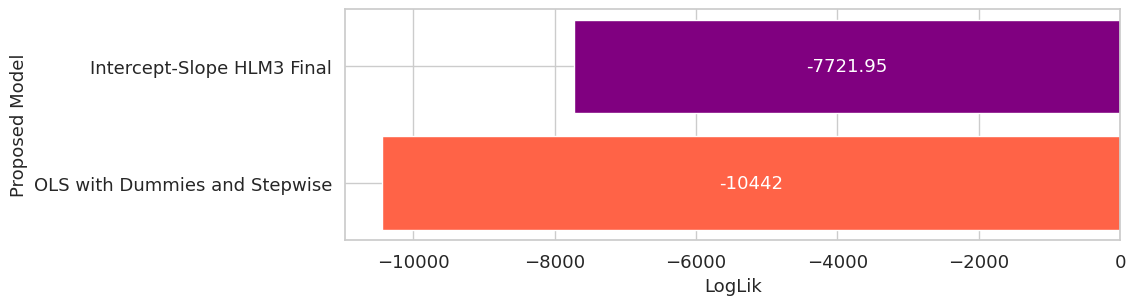

In [88]:
# comparing LogLiks between the ols_dummies_step_model and intercept_slope_hlm3_final_model

llf_df = pd.DataFrame({'model':['OLS with Dummies and Stepwise',
                                'Intercept-Slope HLM3 Final'],
                      'loglik':[ols_dummies_step_model.llf,
                                intercept_slope_hlm3_final_model.llf]})

fig, ax = plt.subplots(figsize=(10,3))

c = ['tomato','purple']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

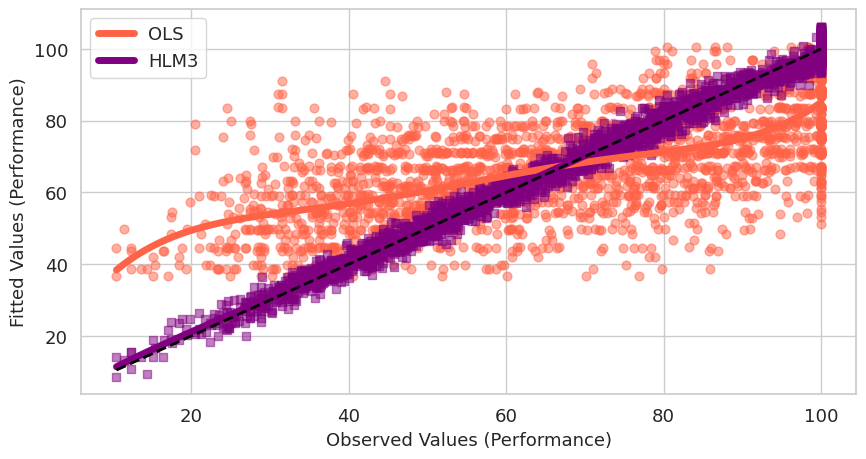

In [94]:
# comparing performance fitted values x observed values using HLM3 final model x OLS with dummies and stepwise model
# what model finally wins between all possible models ? clearly, HLM3 final model.

# OBS.: only when the GLMM random effects on the slope, at higher levels, are not significant, then the OLS with 
# dummies and stepwise gets closer to HLM models, in terms of LogLikelihood score, because HLM random effects on 
# intercepts achieve similar predictability as a dummization process effect on OLS GLM models.

plt.figure(figsize=(10,5))
sns.regplot(x=period_student_school_df['performance'],
            y=ols_dummies_step_model.fittedvalues,
            ci=None, marker='o', order=5,
            scatter_kws={'color':'tomato', 's':40, 'alpha':0.5},
            line_kws={'color':'tomato', 'linewidth':5,
                      'label':'OLS'})
sns.regplot(x=period_student_school_df['performance'],
            y=period_student_school_df['fitted_complete'],
            ci=None, marker='s', order=5,
            scatter_kws={'color':'purple', 's':40, 'alpha':0.5},
            line_kws={'color':'purple', 'linewidth':5,
                      'label':'HLM3'})
sns.regplot(x=period_student_school_df['performance'],
            y=period_student_school_df['performance'],
            ci=None,
            scatter=False,
            line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})
plt.xlabel('Observed Values (Performance)', fontsize=13)
plt.ylabel('Fitted Values (Performance)', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.show()